In [1]:
# This cell is removed with the tag: "remove-input"
# As such, it will not be shown in documentation

import warnings
warnings.filterwarnings('ignore')


(Tutorial_Get_neighbors)=
# Get neighbors

*Finding neighboring atoms or residue groups within a distance threshold or by nearest count.*

The function {func}`molsysmt.structure.get_neighbors` finds surrounding spatial neighbors for a target set of atoms or groups, either by specifying the $k$ nearest neighbors (`n_neighbors`) or a distance cutoff (`threshold`).

:::{versionadded} 1.0.0
:::

:::{admonition} API documentation
:class: dropdown

Follow this link for a detailed description of the input arguments, raised errors, and returned objects of this function: {func}`molsysmt.structure.get_neighbors`.
:::


## Basic usage

Let's show how to find the 3 nearest $C\alpha$ neighbors for each residue in TcTIM (PDB ID: 1TCD):


In [2]:
import molsysmt as msm
import matplotlib.pyplot as plt
import numpy as np


In [3]:
molsys = msm.convert(msm.systems['TcTIM']['1tcd.h5msm'])


:::{note} Demo Systems Catalog
:class: dropdown

This tutorial uses demonstration datasets provided by MolSysMT. To explore the full catalog of bundled systems, forms, and file paths, visit the {ref}`Demo Systems <user-foundations-entrance-demo-systems>` guide.
:::


We select all $C\alpha$ atoms and query their 3 closest neighbors using {func}`molsysmt.structure.get_neighbors` with `n_neighbors=3`:


In [4]:
ca_atoms = msm.select(molsys, selection='atom_name=="CA"')
neighbors, distances = msm.structure.get_neighbors(molsys, selection=ca_atoms, n_neighbors=3)


In [5]:
print('Neighbors array shape:', neighbors.shape)
print('Distances array shape:', distances.shape)
print('Closest 3 neighbors of the first CA atom:', neighbors[0, 0])
print('Distances to closest 3 neighbors:', distances[0, 0])


Neighbors array shape: (1, 497, 3)
Distances array shape: (1, 497, 3)
Closest 3 neighbors of the first CA atom: [  1   2 226]
Distances to closest 3 neighbors: [0.37897700341900714 0.6656387853654624 0.7216471108770198] nanometer


## Cutoff-based neighbor search

Instead of a fixed number of neighbors, we can query all atoms located within a spherical cutoff distance (e.g. `threshold='0.6 nm'`):


In [6]:
neighbors_cut, distances_cut = msm.structure.get_neighbors(molsys, selection=ca_atoms, threshold='0.6 nm')
n_neighbors_per_ca = [len(n_list) for n_list in neighbors_cut[0]]
print(f'Average neighbors within 0.6 nm per CA atom: {np.mean(n_neighbors_per_ca):.1f}')


Average neighbors within 0.6 nm per CA atom: 5.6


## Visualizing neighbor distribution

We plot the distribution of neighbor counts across residues to analyze local packing density:


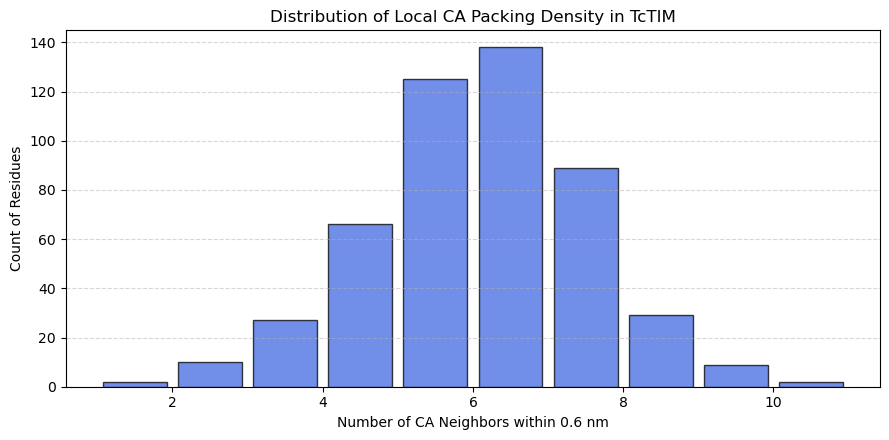

In [7]:
plt.figure(figsize=(9, 4.5))
plt.hist(n_neighbors_per_ca, bins=range(min(n_neighbors_per_ca), max(n_neighbors_per_ca) + 2), color='royalblue', edgecolor='black', alpha=0.75, rwidth=0.85)
plt.xlabel('Number of CA Neighbors within 0.6 nm')
plt.ylabel('Count of Residues')
plt.title('Distribution of Local CA Packing Density in TcTIM')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## Finding inter-chain interface neighbors

We can find residues in Chain 1 that are in spatial contact with residues in Chain 0 by specifying `selection_2`:


In [8]:
ca_chain0 = msm.select(molsys, selection='chain_index==0 and atom_name=="CA"')
ca_chain1 = msm.select(molsys, selection='chain_index==1 and atom_name=="CA"')
interface_neigh, interface_dist = msm.structure.get_neighbors(molsys, selection=ca_chain0, selection_2=ca_chain1, threshold='0.8 nm')

contacting_residues = sum(1 for n in interface_neigh[0] if len(n) > 0)
print(f'Chain 0 residues with at least one Chain 1 neighbor (<0.8 nm): {contacting_residues} / {len(ca_chain0)}')


Chain 0 residues with at least one Chain 1 neighbor (<0.8 nm): 34 / 248


:::{seealso} Related Tools & References
:class: dropdown

- {ref}`Convert <Tutorial_Convert>`: Convert molecular systems between different forms with {func}`molsysmt.basic.convert`.
- {ref}`Select <Tutorial_Select>`: Select atom indices matching boolean or syntax expressions with {func}`molsysmt.basic.select`.
- {ref}`Get distances <Tutorial_Get_distances>`: Compute full pairwise distance matrices with {func}`molsysmt.structure.get_distances`.
- {ref}`Get contacts <Tutorial_Get_contacts>`: Determine binary contact maps with {func}`molsysmt.structure.get_contacts`.
- {ref}`Get minimum distances <Tutorial_Get_minimum_distances>`: Compute closest distance between groups with {func}`molsysmt.structure.get_minimum_distances`.
:::
